| Feature                 | Simple RAG 🟡            | LangGraph ✅                          |
| ----------------------- | ------------------------ | ------------------------------------ |
| Multi-turn conversation | ❌ Manual memory handling | ✅ Built-in state tracking            |
| Tool/Agent integration  | ❌ Hard-coded             | ✅ Easy with modular nodes            |
| Custom logic/routing    | ❌ Fixed flow             | ✅ Dynamic branching between nodes    |
| Retry/Error handling    | ❌ Not built-in           | ✅ Retry & fallback per node          |
| Complex workflows       | ❌ Limited                | ✅ Suitable for multi-agent pipelines |
| Code structure          | 🧱 Monolithic            | 🧩 Modular & reusable (node-based)   |




In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
groq_api_key=os.getenv('GROQ_KEY')
os.environ["LANGCHAIN_API_KEY"] = os.getenv('LANGCHAIN_KEY')
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]="CourseLanggraph"

In [18]:
from langchain_groq import ChatGroq
llm=ChatGroq(groq_api_key=groq_api_key,model_name="Gemma2-9b-It")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x0000022EB2232E40>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022EB2233A10>, model_name='Gemma2-9b-It', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [8]:
# Messages have the type "list". The `add_messages` function
# in the annotation defines how this state key should be updated
# (in this case, it appends messages to the list, rather than overwriting them)
class State(TypedDict):
  messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)


In [9]:
graph_builder


In [10]:
def chatbot(state:State):
  return {"messages":llm.invoke(state['messages'])}

In [11]:
graph_builder.add_node("chatbot",chatbot) #Adding a node chatbot

In [13]:
#connecting nodes to start and end using edges
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

In [14]:
graph=graph_builder.compile()

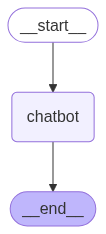

In [15]:
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [19]:
while True:
  user_input=input("User: ")
  if user_input.lower() in ["quit","q"]:
    print("Good Bye")
    break
  for event in graph.stream({'messages':("user",user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:",value["messages"].content)

dict_values([{'messages': AIMessage(content="Sachin Tendulkar is widely regarded as **one of the greatest cricketers of all time**. \n\nHere are some key facts about him:\n\n* **Full Name:** Sachin Ramesh Tendulkar\n* **Born:** April 24, 1973, in Mumbai, India\n* **Nicknames:** The Little Master, God of Cricket\n* **Batting Style:** Right-handed\n* **Bowling Style:** Right-arm off break\n* **International Career:** 1989-2013\n* **Teams:** India (national team), Mumbai (domestic team)\n\n**Achievements:**\n\n* **Highest run-scorer in both Test and ODI cricket:** He holds numerous records, including the most runs in both formats of the game.\n* **100 International Centuries:** A feat unmatched by any other cricketer.\n* **First batsman to score a double century in ODI cricket:** He achieved this milestone in 2010.\n* **Bharat Ratna:** India's highest civilian award, bestowed upon him in 2014 for his exceptional contribution to cricket.\n\n**Legacy:**\n\n* **Icon of Indian Cricket:** Tend